In [1]:
import torch
import matplotlib.pyplot as plt

from model_ranking import (
    UnetrWrapper,
    FeatureExtractor,
)
from pytorch3dunet.unet3d.model import UNet2D, ResidualUNet2D


INFO: P [MainThread] 2025-11-01 22:26:50,729 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import umap
import numpy as np
from pathlib import Path
from typing import Optional, Union, Any
from numpy.typing import NDArray

def compute_umap_embedding(
    features: Union[torch.Tensor, NDArray[Any]], 
    save_path: Optional[str] = None, 
    save_name: Optional[str] = None, 
    n_neighbors:int=15, 
    min_dist:float=0.1, 
    random_state:int=42,
    normalize: Optional[str] = 'l2',
    metric: str = 'cosine'
):
    """
    Compute UMAP embedding from feature maps.
    
    Parameters:
    -----------
    features : torch.Tensor or np.ndarray
        Feature tensor of shape (B, C, H, W) or (C, H, W) where B is batch size, 
        C is number of channels, H and W are spatial dimensions.
    save_path : str or Path, optional
        If provided, save the embedding to this path as a .npy file.
    n_neighbors : int
        Number of neighbors for UMAP algorithm.
    min_dist : float
        Minimum distance parameter for UMAP algorithm.
    random_state : int
        Random state for reproducibility.
    normalize : str or None, optional
        Normalization method to apply to features. Options:
        - 'l2': L2 normalization (unit norm) - recommended for semantic segmentation
        - 'standardize': Z-score normalization (mean=0, std=1)
        - 'minmax': Min-max normalization to [0, 1]
        - None: No normalization
    metric : str
        Distance metric for UMAP. Options include:
        - 'cosine': Cosine distance (recommended for deep learning features)
        - 'euclidean': Euclidean distance
        - 'correlation': Pearson correlation distance
        - 'manhattan': Manhattan distance
    
    Returns:
    --------
    embedding : np.ndarray
        The 2D UMAP embedding of shape (H*W, 2).
    """
    # Convert to numpy if needed
    if torch.is_tensor(features):
        features = features.detach().cpu().numpy()
    
    # Handle batch dimension
    if features.ndim == 4:
        features = features.squeeze(0)  # Remove batch dimension: (C, H, W)
    
    # Reshape features: (C, H, W) -> (H*W, C)
    C, H, W = features.shape
    features_reshaped = features.reshape(C, -1).T  # Shape: (H*W, C)
    
    print(f"Feature shape for UMAP: {features_reshaped.shape}")
    
    # Apply normalization
    if normalize is not None:
        print(f"Applying {normalize} normalization...")
        if normalize == 'l2':
            # L2 normalization (unit norm)
            norms = np.linalg.norm(features_reshaped, axis=1, keepdims=True)
            norms = np.where(norms == 0, 1, norms)  # Avoid division by zero
            features_reshaped = features_reshaped / norms
        elif normalize == 'standardize':
            # Z-score normalization
            mean = features_reshaped.mean(axis=0, keepdims=True)
            std = features_reshaped.std(axis=0, keepdims=True)
            std = np.where(std == 0, 1, std)  # Avoid division by zero
            features_reshaped = (features_reshaped - mean) / std
        elif normalize == 'minmax':
            # Min-max normalization
            min_val = features_reshaped.min(axis=0, keepdims=True)
            max_val = features_reshaped.max(axis=0, keepdims=True)
            range_val = max_val - min_val
            range_val = np.where(range_val == 0, 1, range_val)  # Avoid division by zero
            features_reshaped = (features_reshaped - min_val) / range_val
        else:
            raise ValueError(f"Unknown normalization method: {normalize}")
    
    # Perform UMAP
    print(f"Running UMAP with {metric} metric...")
    reducer = umap.UMAP(
        n_neighbors=n_neighbors, 
        min_dist=min_dist, 
        metric=metric,
        random_state=random_state
    )
    embedding = reducer.fit_transform(features_reshaped)
    
    print(f"UMAP embedding shape: {embedding.shape}")
    
    # Save embedding if path is provided
    if save_path is not None:
        if save_name is None:
            save_name = 'Feature_UMAP'
        save_path = Path(save_path) / save_name
        save_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(save_path, embedding)
        print(f"Embedding saved to {save_path}")
    
    return embedding


def plot_umap_embedding(embedding, labels, title="UMAP Feature Space", figsize=(10, 8), 
                        cmap='viridis', s=1, alpha=0.5):
    """
    Plot UMAP embedding colored by ground truth labels.
    
    Parameters:
    -----------
    embedding : np.ndarray
        The 2D UMAP embedding of shape (N, 2) where N is the number of points.
    labels : torch.Tensor or np.ndarray
        Label tensor of shape (B, 1, H, W) or (H, W) containing labels.
        Will be flattened to match the embedding shape.
    title : str
        Title for the plot.
    figsize : tuple
        Figure size for the plot.
    cmap : str
        Colormap for the scatter plot.
    s : float
        Size of scatter points.
    alpha : float
        Transparency of scatter points.
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    # Convert to numpy if needed
    if torch.is_tensor(labels):
        labels = labels.detach().cpu().numpy()
    
    # Handle batch and channel dimensions
    if labels.ndim == 4:
        labels = labels.squeeze(0).squeeze(0)  # Remove batch and channel dimensions: (H, W)
    elif labels.ndim == 3:
        labels = labels.squeeze(0)  # Remove channel dimension: (H, W)
    
    # Flatten labels: (H, W) -> (H*W,)
    labels_flat = labels.flatten()
    
    print(f"Embedding shape: {embedding.shape}")
    print(f"Label shape: {labels_flat.shape}")
    print(f"Unique labels: {np.unique(labels_flat)}")
    
    # Verify shapes match
    assert embedding.shape[0] == labels_flat.shape[0], \
        f"Embedding and labels shape mismatch: {embedding.shape[0]} vs {labels_flat.shape[0]}"
    
    # Create visualization
    fig, ax = plt.subplots(figsize=figsize)
    
    # Get unique labels
    unique_labels = np.unique(labels_flat)
    
    # Plot each label class separately for legend
    for label_val in unique_labels:
        mask = labels_flat == label_val
        _ = ax.scatter(
            embedding[mask, 0], 
            embedding[mask, 1], 
            label=f'Label {int(label_val)}',
            s=s, 
            alpha=alpha
        )
    
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('UMAP 1', fontsize=12)
    ax.set_ylabel('UMAP 2', fontsize=12)
    
    # Add legend
    ax.legend(loc='best', fontsize=10, markerscale=5)
    
    plt.tight_layout()

    plt.show()
    
    return fig, ax

In [3]:
from typing import Any, Dict
from torch.utils.data import ConcatDataset, DataLoader
from model_ranking import (
    semantic_loaders_type,
    loader_classes,
    Pytorch3DUnetTrainLoaderConfig,
    Pytorch3DUnetLoaderMetaConfig,
    Pytorch3DUnetSliceBuilderConfig,
)


def get_datasets(
    config: semantic_loaders_type,
):
    # get dataset class
    dataset_cls_str = config.dataset
    dataset_class = loader_classes(dataset_cls_str)
    datasets = dataset_class.create_datasets(config.model_dump(), phase="train")
    return datasets

def initialise_target_datasets(# pyright: ignore
    loader_config: Pytorch3DUnetLoaderMetaConfig,
):

    target_dataset_cfg = loader_config.create_config(
        output_dir=None,
        data_base_path="/scratch/talks/data",
        phase="train",
    )
    assert isinstance(
        target_dataset_cfg,
        (
            Pytorch3DUnetTrainLoaderConfig,
        ),
    ), f"Expected semantic loader config type, got {type(target_dataset_cfg).__name__}"
    datasets = get_datasets(target_dataset_cfg)
    target_dataset  = ConcatDataset(datasets) # pyright: ignore
    target_dataloader = DataLoader(# pyright: ignore
        target_dataset,# pyright: ignore
        batch_size=target_dataset_cfg.batch_size,
        shuffle=False,
        pin_memory=True,
        num_workers=target_dataset_cfg.num_workers,
    )

    return target_dataset, target_dataloader# pyright: ignore

In [4]:
EPFL_loader_cfg: Pytorch3DUnetLoaderMetaConfig = Pytorch3DUnetLoaderMetaConfig(
        dataset="StandardHDF5Dataset",
        batch_size=10,
        num_workers=8,
        raw_internal_path="raw",
        label_internal_path="labels",
        global_normalization=True,
        #global_normalization=False,
        global_percentiles=None,
        file_paths=("/EPFL/test.h5",),
        roi=None,
        transformer={
            "raw": [
                {"name": "Normalize"},
                {"name": "ToTensor", "expand_dims": True},
            ],
            "label": [
                {"name": "ToTensor", "expand_dims": True},
            ],
        },
        slice_builder=Pytorch3DUnetSliceBuilderConfig(
            name="SliceBuilder",
            patch_shape=(1, 256, 256),
            stride_shape=(1, 256, 256),
            halo_shape=(0, 32, 32),
        ),
    )

dataset, dataloader = initialise_target_datasets(EPFL_loader_cfg)

2025-11-01 22:26:56,368 [MainThread] INFO HDF5Dataset - Loading train set from: /scratch/talks/data/EPFL/test.h5...
2025-11-01 22:26:56,371 [MainThread] INFO HDF5Dataset - Auto-calculated padding: [0, 0, 0] for patch_shape: (1, 256, 256) and volume_shape: (125, 480, 640)
2025-11-01 22:26:56,372 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
2025-11-01 22:26:56,371 [MainThread] INFO HDF5Dataset - Auto-calculated padding: [0, 0, 0] for patch_shape: (1, 256, 256) and volume_shape: (125, 480, 640)
2025-11-01 22:26:56,372 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 0.5599145293235779, global std: 0.11937469989061356
2025-11-01 22:26:56,601 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': (1, 256, 256), 'stride_shape': (1, 256, 256), 'halo_shape': (0, 32, 32)}
2025-11-01 22:26:56,604 [MainThread] INFO HDF5Dataset - Number of patches: 750
Global mean: 0.5599145293235779, global s

torch.Size([1, 1, 256, 256]) torch.Size([1, 1, 256, 256])


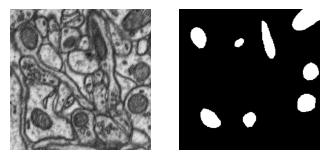

In [5]:
raw, label = dataset[433]
print(raw.shape, label.shape)
_, axs = plt.subplots(1, 2, figsize=(4, 8))
axs[0].imshow(raw.numpy().squeeze(), cmap='grey')
axs[0].axis('off')
axs[1].imshow(label.numpy().squeeze(), cmap='grey')
axs[1].axis('off')
plt.show()

# Source Models

### E_model5

In [6]:
EtoE_UN_ckpt_path = "/g/kreshuk/talks/segmentation_ModelSelection/experiments/EPFL/BatchNorm/E_model5/best_checkpoint.pytorch"
model_config: Dict[str, Any] = {
    "name": "UNet2D",
    "in_channels": 1,
    "out_channels": 1,
    "layer_order": "bcr",
    "f_maps": 32,
    "final_sigmoid": True,
    "is_segmentation": True
}

EtoE_UN_model = UNet2D(**model_config)
_ = EtoE_UN_model.load_state_dict(torch.load(EtoE_UN_ckpt_path)["model_state_dict"])
_ = EtoE_UN_model.eval()

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [7]:
layers = ["decoders.2"]

with torch.no_grad():
    EtoE_UN_feature_extractor = FeatureExtractor(EtoE_UN_model, layers)
    raw, label = dataset[433]
    EtoE_UN_model = EtoE_UN_model.eval()
    EtoE_UN_pred = EtoE_UN_model(raw) > 0.5
    print(EtoE_UN_pred.shape)

    EtoE_UN_features_out, _, _ = EtoE_UN_feature_extractor(raw)
    print(EtoE_UN_features_out['decoders.2'].shape)

torch.Size([1, 1, 256, 256])
torch.Size([1, 32, 256, 256])


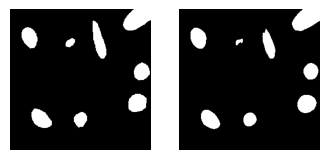

In [8]:
_, axs = plt.subplots(1, 2, figsize=(4, 8))
axs[0].imshow(label.numpy().squeeze(), cmap='grey')
axs[0].axis('off')
axs[1].imshow(EtoE_UN_pred.numpy().squeeze(), cmap='grey')
axs[1].axis('off')
plt.show()

Feature shape for UMAP: (65536, 32)
Applying standardize normalization...
Running UMAP with cosine metric...


n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP embedding shape: (65536, 2)
Embedding saved to embeddings/semantic_standardized/EtoE_U-Net_embedding.npy
Embedding shape: (65536, 2)
Label shape: (65536,)
Unique labels: [0. 1.]


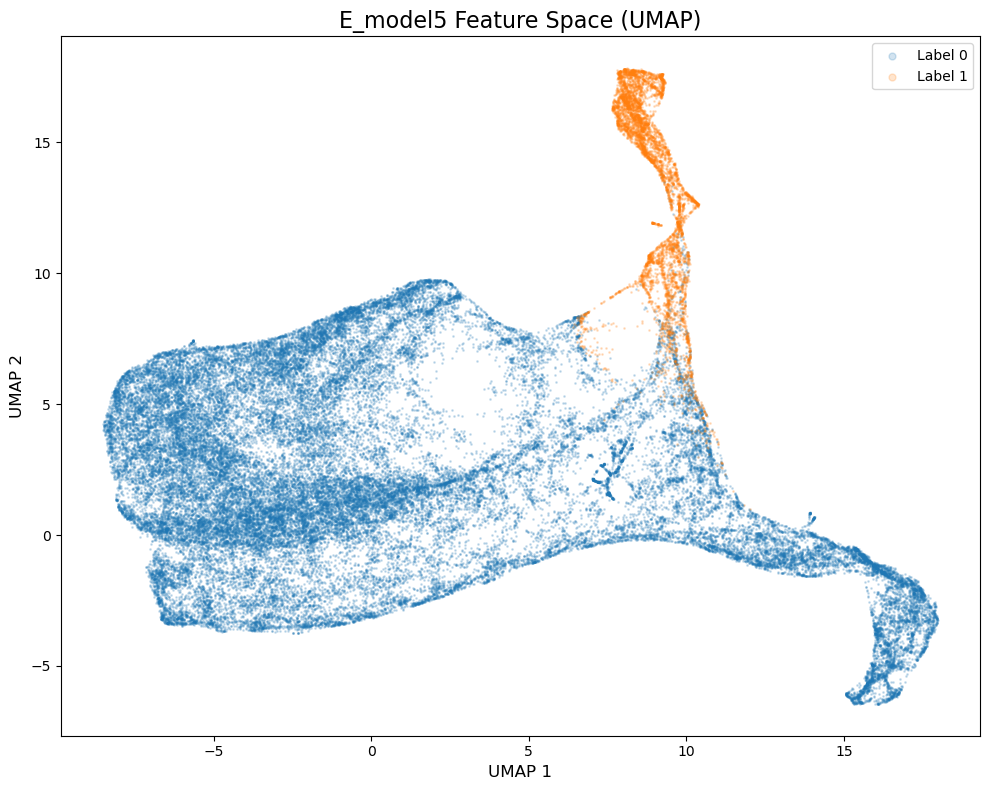

Embedding shape: (65536, 2)
Label shape: (65536,)
Unique labels: [False  True]


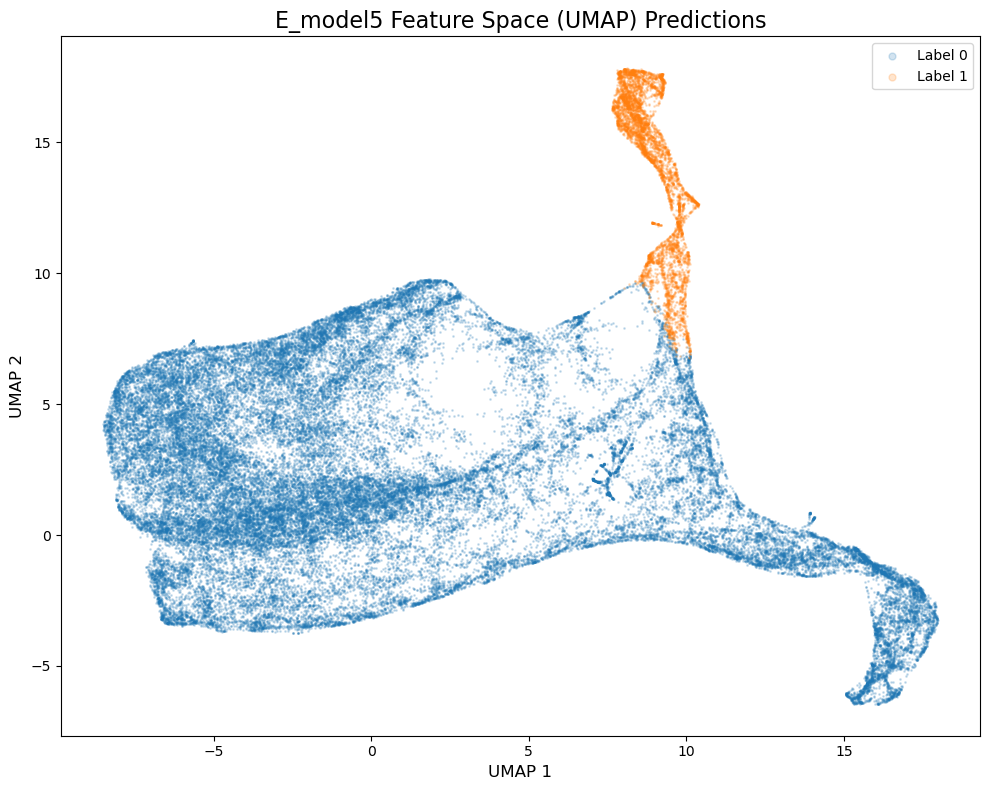

In [9]:
# Example usage: Compute UMAP embedding and save it
embedding = compute_umap_embedding(
    EtoE_UN_features_out['decoders.2'], 
    save_path='./embeddings/semantic_standardized',  # Optional: save embedding
    save_name='EtoE_U-Net_embedding.npy',
    n_neighbors=50,
    min_dist=0.1,
    normalize='standardize'
)

#embedding = np.load('/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/embeddings/semantic_seg_EPFL_target/EtoE_U-Net_embedding.npy')

# Plot the embedding
_ = plot_umap_embedding(
    embedding,
    label,
    title="E_model5 Feature Space (UMAP)",
    alpha=0.2,
    s=1
)

_ = plot_umap_embedding(
    embedding,
    EtoE_UN_pred,
    title="E_model5 Feature Space (UMAP) Predictions",
    alpha=0.2,
    s=1
)


### Hm_model_Res1

In [10]:
HtoE_Res_ckpt_path = "/g/kreshuk/talks/segmentation_ModelSelection/experiments/Hmito/BatchNorm/Hm_model_Res1/best_checkpoint.pytorch"
model_config: Dict[str, Any] = {
    "name": "ResidualUNet2D",
    "in_channels": 1,
    "out_channels": 1,
    "layer_order": "bcr",
    "f_maps": 64,
    "final_sigmoid": True,
    "is_segmentation": True
}

HtoE_Res_model = ResidualUNet2D(**model_config)
_ = HtoE_Res_model.load_state_dict(torch.load(HtoE_Res_ckpt_path)["model_state_dict"])
_ = HtoE_Res_model.eval()
#print(HtoE_Res_model)

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [11]:
layers = ["decoders.3"]
with torch.no_grad():
    HtoE_Res_feature_extractor = FeatureExtractor(HtoE_Res_model, layers)
    raw, label = dataset[433]

    with torch.no_grad():
        HtoE_Res_model = HtoE_Res_model.eval()
        HtoE_Res_pred = HtoE_Res_model(raw) > 0.5
    print(HtoE_Res_pred.shape)

    HtoE_Res_features_out, _, _ = HtoE_Res_feature_extractor(raw)
    print(HtoE_Res_features_out['decoders.3'].shape)


torch.Size([1, 1, 256, 256])
torch.Size([1, 64, 256, 256])


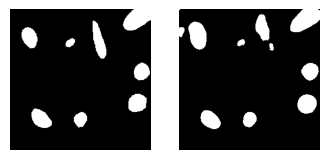

In [12]:
_, axs = plt.subplots(1, 2, figsize=(4, 8))
axs[0].imshow(label.numpy().squeeze(), cmap='grey')
axs[0].axis('off')
axs[1].imshow(HtoE_Res_pred.numpy().squeeze(), cmap='grey')
axs[1].axis('off')
plt.show()

Feature shape for UMAP: (65536, 64)
Applying standardize normalization...
Running UMAP with cosine metric...
Running UMAP with cosine metric...


n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP embedding shape: (65536, 2)
Embedding saved to embeddings/semantic_standardized/HtoE_Res_embedding.npy
Embedding shape: (65536, 2)
Label shape: (65536,)
Unique labels: [0. 1.]


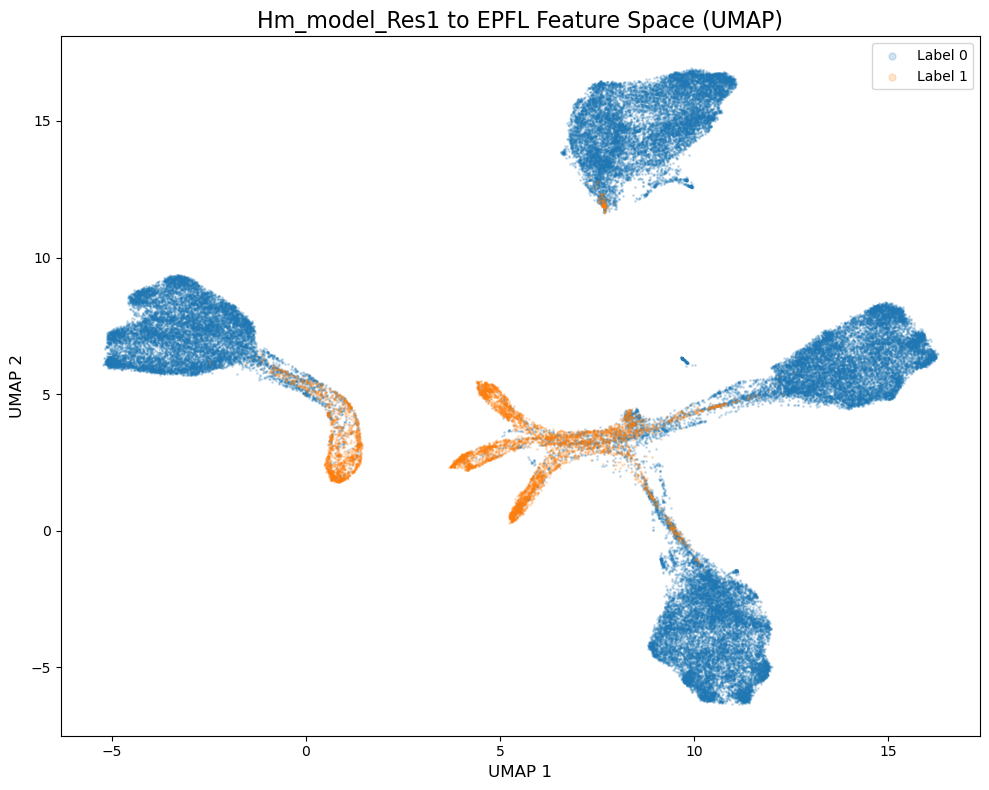

Embedding shape: (65536, 2)
Label shape: (65536,)
Unique labels: [False  True]


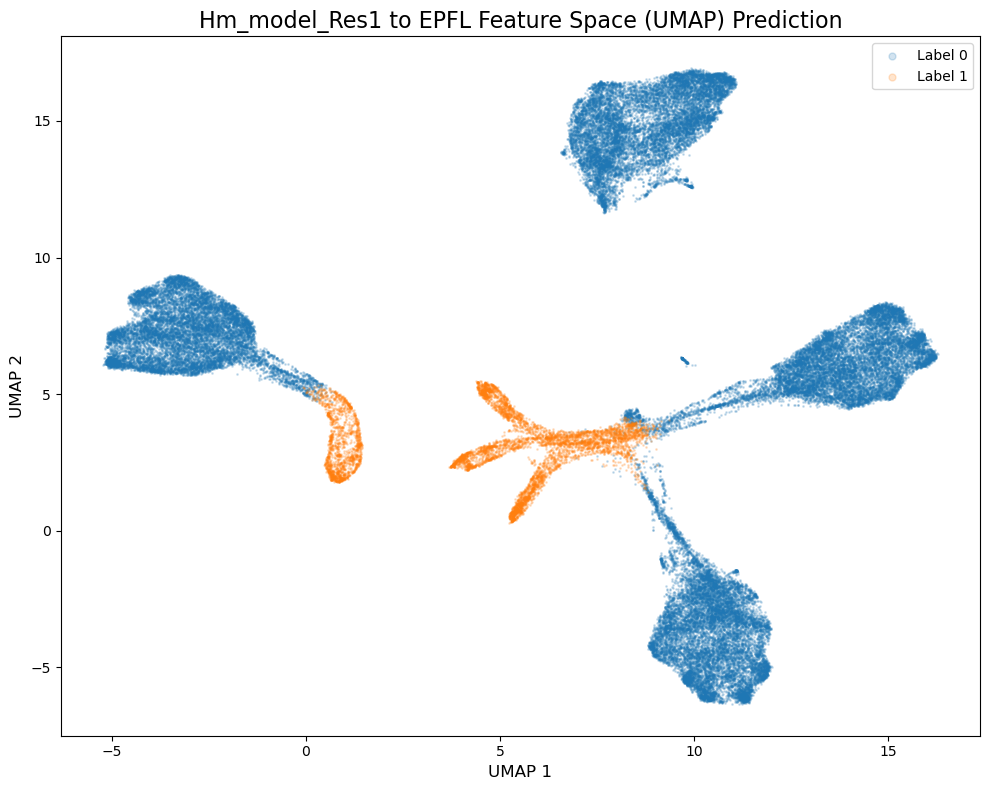

In [13]:
embedding = compute_umap_embedding(
    HtoE_Res_features_out['decoders.3'], 
    save_path='./embeddings/semantic_standardized',  # Optional: save embedding
    save_name='HtoE_Res_embedding.npy',
    n_neighbors=50,
    min_dist=0.1,
    normalize='standardize'
)
#embedding_path = "/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/embeddings/semantic_seg_EPFL_target/HtoE_Res_embedding.npy"
#embedding = np.load(embedding_path)

# Plot the embedding
_ = plot_umap_embedding(
    embedding,
    label,
    title="Hm_model_Res1 to EPFL Feature Space (UMAP)",
    alpha=0.2,
)
_ = plot_umap_embedding(
    embedding,
    HtoE_Res_pred,
    title="Hm_model_Res1 to EPFL Feature Space (UMAP) Prediction",
    alpha=0.2,
)

### Rm_model_NA2

In [14]:
RtoE_NA_ckpt_path = "/g/kreshuk/talks/segmentation_ModelSelection/experiments/Rmito/BatchNorm/Rm_model_NA2/best_checkpoint.pytorch"
model_config: Dict[str, Any] = {
    "name": "UNet2D",
    "in_channels": 1,
    "out_channels": 1,
    "layer_order": "bcr",
    "f_maps": 32,
    "final_sigmoid": True,
    "is_segmentation": True,
    "dropout_prob": 0
}

RtoE_NA_model = UNet2D(**model_config)
_ = RtoE_NA_model.load_state_dict(torch.load(RtoE_NA_ckpt_path)["model_state_dict"])
_ = RtoE_NA_model.eval()
#print(RtoE_NA_model)

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [15]:
layers = ["decoders.2"]
with torch.no_grad():
    RtoE_NA_feature_extractor = FeatureExtractor(RtoE_NA_model, layers)
    raw, label = dataset[433]

    RtoE_NA_pred = RtoE_NA_model(raw) > 0.5
    print(RtoE_NA_pred.shape)

    RtoE_NA_features_out, _, _ = RtoE_NA_feature_extractor(raw)
    print(RtoE_NA_features_out['decoders.2'].shape)

torch.Size([1, 1, 256, 256])
torch.Size([1, 32, 256, 256])


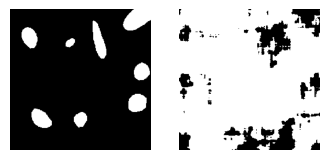

In [16]:
_, axs = plt.subplots(1, 2, figsize=(4, 8))
axs[0].imshow(label.numpy().squeeze(), cmap='grey')
axs[0].axis('off')
axs[1].imshow(RtoE_NA_pred.numpy().squeeze(), cmap='grey')
axs[1].axis('off')
plt.show()

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Feature shape for UMAP: (65536, 32)
Applying standardize normalization...
Running UMAP with cosine metric...


UMAP embedding shape: (65536, 2)
Embedding saved to embeddings/semantic_standardized/RtoE_NA_embedding.npy
Embedding shape: (65536, 2)
Label shape: (65536,)
Unique labels: [0. 1.]


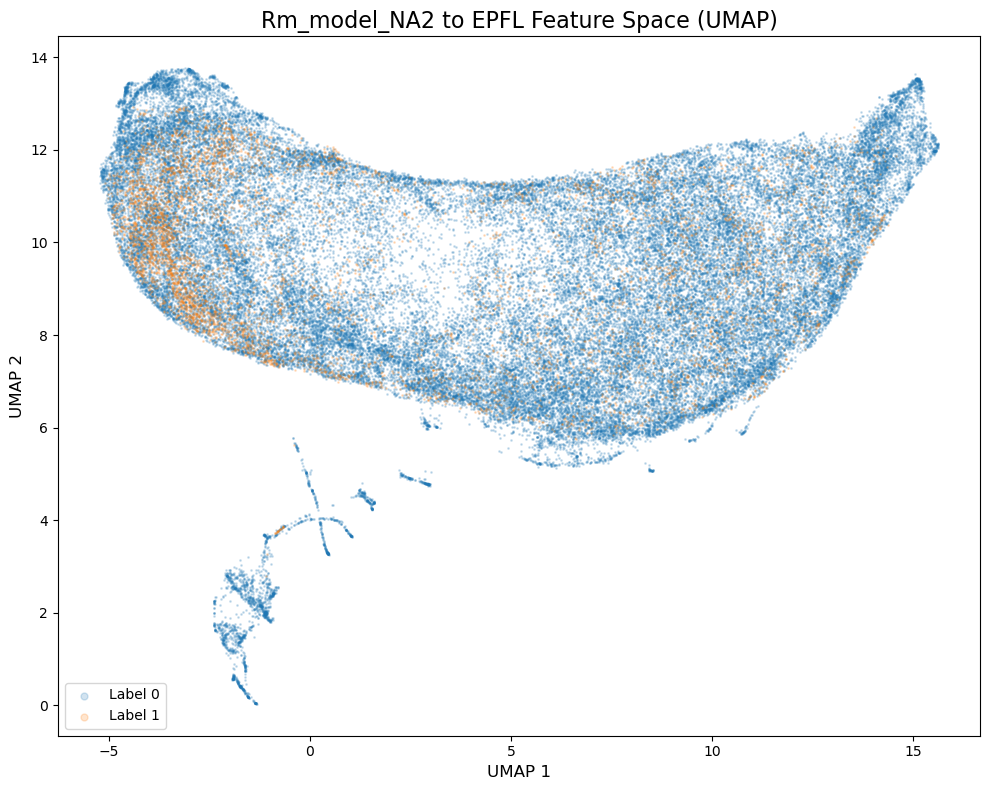

Embedding shape: (65536, 2)
Label shape: (65536,)
Unique labels: [False  True]


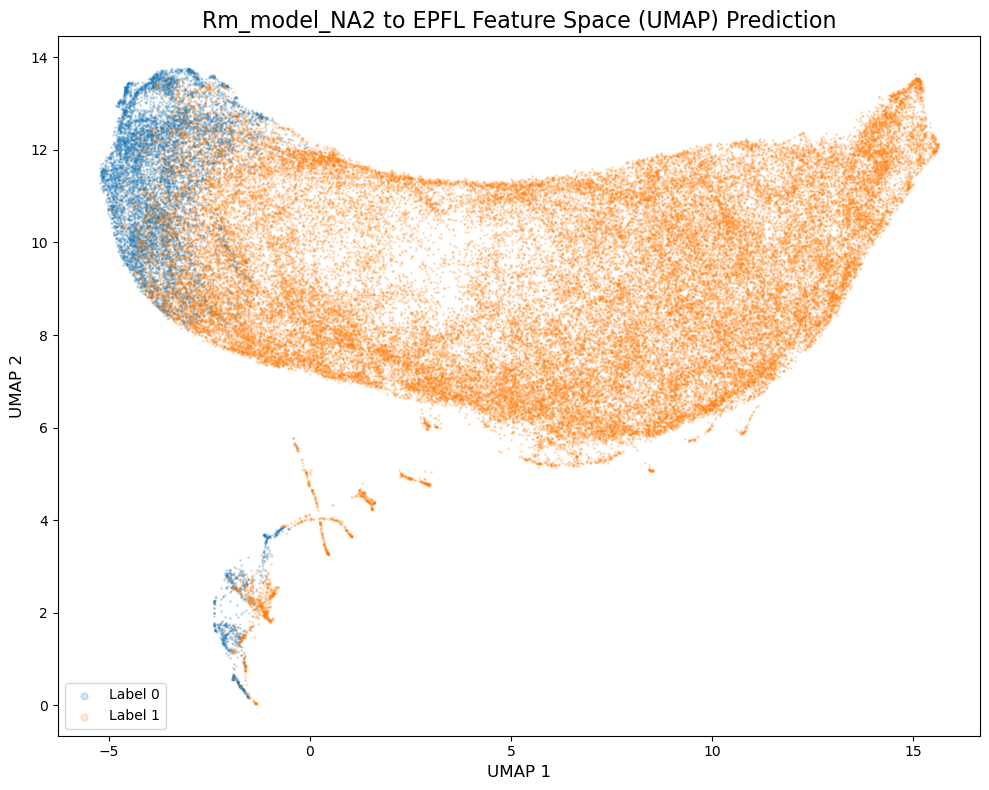

In [17]:
embedding = compute_umap_embedding(
    RtoE_NA_features_out['decoders.2'], 
    save_path='./embeddings/semantic_standardized',  # Optional: save embedding
    save_name="RtoE_NA_embedding.npy",
    n_neighbors=50,
    min_dist=0.1,
    normalize='standardize'
)
# embedding_path = "/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/embeddings/semantic_seg_EPFL_target/RtoE_NA_embedding.npy"
# embedding = np.load(embedding_path)


# Plot the embedding
_ = plot_umap_embedding(
    embedding,
    label,
    title="Rm_model_NA2 to EPFL Feature Space (UMAP)",
    alpha=0.2,
)
# Label by prediction
_ = plot_umap_embedding(
    embedding,
    RtoE_NA_pred,
    title="Rm_model_NA2 to EPFL Feature Space (UMAP) Prediction",
    alpha=0.2,
)

### Rm_model_Unetr2

In [18]:
RtoE_UNr_ckpt_path = "/g/kreshuk/talks/segmentation_ModelSelection/experiments/Rmito/BatchNorm/Rm_model_Unetr2/best_checkpoint.pytorch"
model_config: Dict[str, Any] = {
    "name": "UnetrWrapper",
    "in_channels": 1,
    "out_channels": 1,
    "img_size": 256,
    "feature_size": 16,
    "hidden_size": 768,
    "mlp_dim": 3072,
    "num_heads": 12,
    "proj_type": "conv",
    "norm_name": "batch",
    "conv_block": True,
    "res_block": True,
    "dropout_rate": 0.0,
    "spatial_dims": 2,
    "qkv_bias": False,
    "save_attn": False,
    "is_segmentation": True,
    "final_sigmoid": True
}

RtoE_UNr_model = UnetrWrapper(**model_config)
_ = RtoE_UNr_model.load_state_dict(torch.load(RtoE_UNr_ckpt_path)["model_state_dict"])
_ = RtoE_UNr_model.eval()
#print(RtoE_UNr_model)

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [19]:
layers = ["decoder2"]
with torch.no_grad():
    RtoE_UNr_feature_extractor = FeatureExtractor(RtoE_UNr_model, layers)
    raw, label = dataset[433]
    RtoE_Unr_pred = RtoE_UNr_model(raw) > 0.5
    print(RtoE_Unr_pred.shape)

    RtoE_UNr_features_out, _, _ = RtoE_UNr_feature_extractor(raw)
    print(RtoE_UNr_features_out['decoder2'].shape)

torch.Size([1, 1, 1, 256, 256])
torch.Size([1, 16, 256, 256])
torch.Size([1, 16, 256, 256])


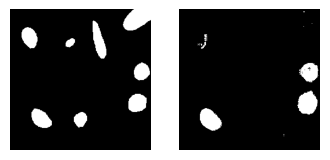

In [20]:
_, axs = plt.subplots(1, 2, figsize=(4, 8))
axs[0].imshow(label.numpy().squeeze(), cmap='grey')
axs[0].axis('off')
axs[1].imshow(RtoE_Unr_pred.numpy().squeeze(), cmap='grey')
axs[1].axis('off')
plt.show()

Feature shape for UMAP: (65536, 16)
Applying standardize normalization...
Running UMAP with cosine metric...


n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP embedding shape: (65536, 2)
Embedding saved to embeddings/semantic_standardized/RtoE_UNr_embedding.npy
Embedding shape: (65536, 2)
Label shape: (65536,)
Unique labels: [0. 1.]


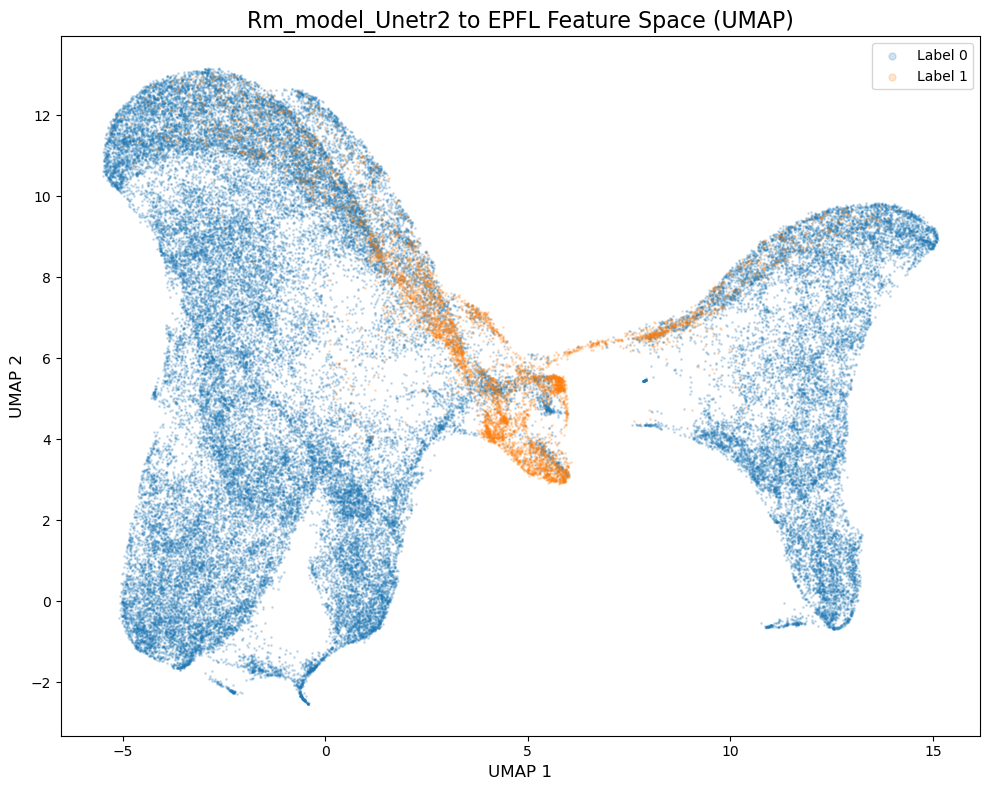

Embedding shape: (65536, 2)
Label shape: (65536,)
Unique labels: [False  True]


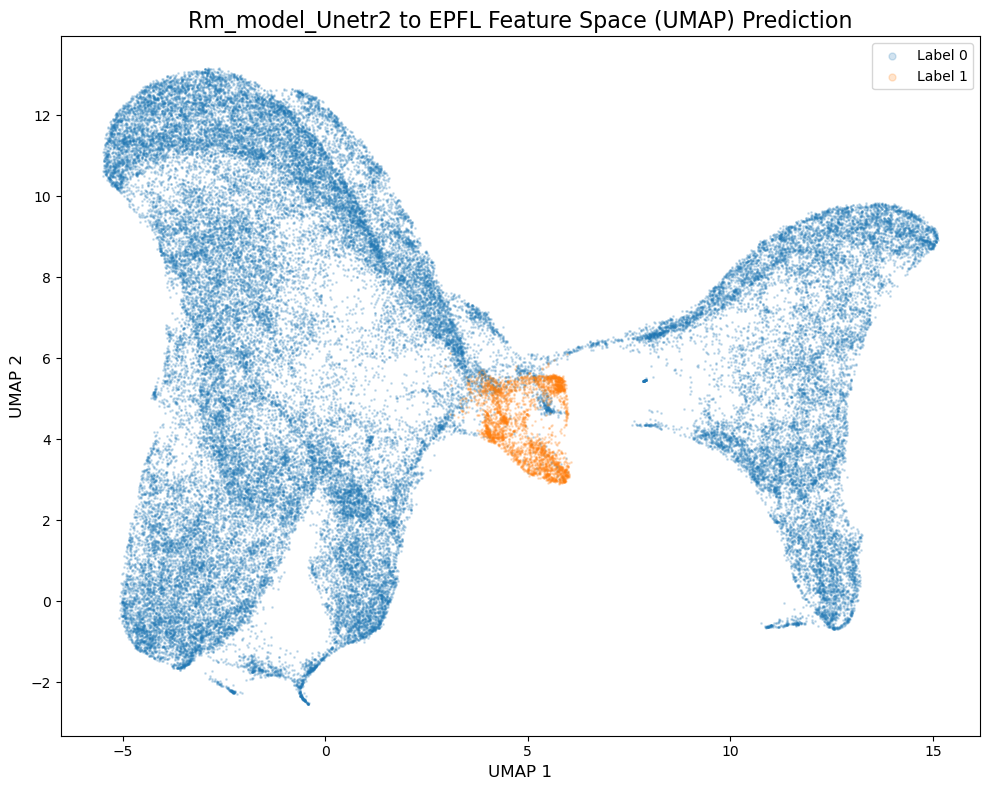

In [21]:
embedding = compute_umap_embedding(
    RtoE_UNr_features_out['decoder2'], 
    save_path='./embeddings/semantic_standardized',  # Optional: save embedding
    save_name="RtoE_UNr_embedding.npy",
    n_neighbors=50,
    min_dist=0.1,
    normalize='standardize'
)
# embedding_path = "/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/embeddings/semantic_seg_EPFL_target/RtoE_UNr_embedding.npy"
# embedding = np.load(embedding_path)

# Plot the embedding
_ = plot_umap_embedding(
    embedding,
    label,
    title="Rm_model_Unetr2 to EPFL Feature Space (UMAP)",
    alpha=0.2
)
# Label by prediction
_ = plot_umap_embedding(
    embedding,
    RtoE_Unr_pred,
    title="Rm_model_Unetr2 to EPFL Feature Space (UMAP) Prediction",
    alpha=0.2,
)